# 05 — EDA & Business Analytics

**Tujuan notebook ini (Fase 5 roadmap):**
- 5.1 Sales Performance
- 5.2 Customer Analytics
- 5.3 Product Analytics
- 5.4 Seller Analytics
- 5.5 Delivery Analytics

> Notebook ini pakai `customer_analytics_full`, `product_analytics`, `seller_analytics` dari `data_processed/` (hasil notebook 04) — jalur **Business Analytics**, bukan ML. Terminologi konsisten: **`transaction_value`**, bukan "revenue" (lihat catatan Fase 3.3).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
from pathlib import Path

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

DATA_DIR = Path("../data_processed")
customer_analytics_full = pd.read_csv(DATA_DIR / "customer_analytics.csv", parse_dates=["first_order_date", "last_order_date"])
product_analytics = pd.read_csv(DATA_DIR / "product_analytics.csv")
seller_analytics = pd.read_csv(DATA_DIR / "seller_analytics.csv")

MONGO_URI = "mongodb://localhost:27017/"
client = MongoClient(MONGO_URI)
db = client["olist_db"]

orders = pd.DataFrame(list(db["orders_raw"].find({}, {"_id": 0})))
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], errors="coerce")
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"], errors="coerce")
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"], errors="coerce")
orders["delivery_days"] = (orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]).dt.days

payments = pd.DataFrame(list(db["payments_raw"].find({}, {"_id": 0})))
transaction_value_per_order = payments.groupby("order_id")["payment_value"].sum().rename("transaction_value")
orders = orders.merge(transaction_value_per_order, on="order_id", how="left")

print("Data siap. customer_analytics_full:", customer_analytics_full.shape,
      "| product_analytics:", product_analytics.shape,
      "| seller_analytics:", seller_analytics.shape)


Data siap. customer_analytics_full: (96096, 8) | product_analytics: (32951, 7) | seller_analytics: (3095, 6)


---
## 5.1 Sales Performance

Total transaction value, growth trend, bulan tertinggi, kategori terbesar.


In [2]:
total_transaction_value = orders["transaction_value"].sum()
print(f"Total Transaction Value (Payment Value Proxy): {total_transaction_value:,.2f}")
print(f"Total Orders: {orders['order_id'].nunique():,}")

orders["order_month_period"] = orders["order_purchase_timestamp"].dt.to_period("M")
monthly_trend = orders.groupby("order_month_period")["transaction_value"].sum()

# Exclude bulan pertama & terakhir kalau datanya tidak lengkap (Sep 2016 & Sep/Okt 2018 biasanya parsial)
print("\n5 bulan dengan transaction value tertinggi:")
print(monthly_trend.sort_values(ascending=False).head())


Total Transaction Value (Payment Value Proxy): 16,008,872.12
Total Orders: 99,441

5 bulan dengan transaction value tertinggi:
order_month_period
2017-11    1194882.80
2018-04    1160785.48
2018-03    1159652.12
2018-05    1153982.15
2018-01    1115004.18
Freq: M, Name: transaction_value, dtype: float64


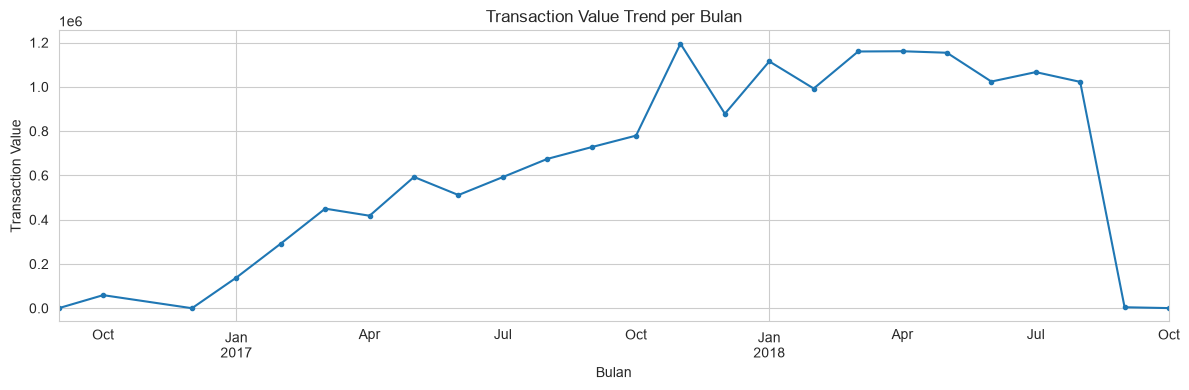

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
monthly_trend.plot(kind="line", ax=ax, marker="o", markersize=3)
ax.set_title("Transaction Value Trend per Bulan")
ax.set_xlabel("Bulan")
ax.set_ylabel("Transaction Value")
plt.tight_layout()
plt.show()


Top 10 kategori berdasarkan transaction value:
category
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: transaction_value, dtype: float64


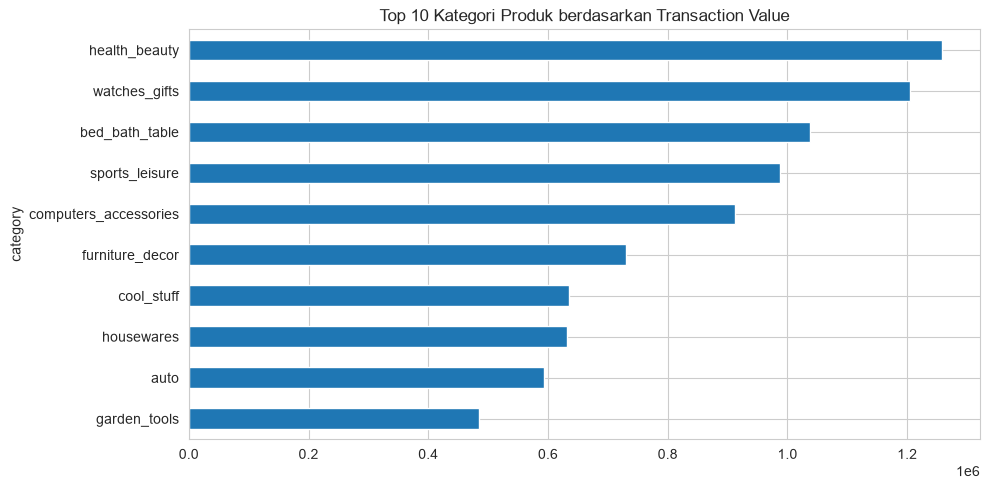

In [4]:
top_categories = product_analytics.groupby("category")["transaction_value"].sum().sort_values(ascending=False).head(10)
print("Top 10 kategori berdasarkan transaction value:")
print(top_categories)

fig, ax = plt.subplots(figsize=(10, 5))
top_categories.plot(kind="barh", ax=ax)
ax.set_title("Top 10 Kategori Produk berdasarkan Transaction Value")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


---
## 5.2 Customer Analytics

Total customers, repeat customers, avg spending, frekuensi, distribusi per state.


In [5]:
print(f"Total unique customer (customer_unique_id): {customer_analytics_full.shape[0]:,}")
print(f"Repeat customers (total_orders > 1): {(customer_analytics_full['total_orders'] > 1).sum():,}")
print(f"Average spending per customer: {customer_analytics_full['total_spending'].mean():,.2f}")
print(f"Average orders per customer: {customer_analytics_full['total_orders'].mean():.2f}")

top_states = customer_analytics_full["customer_state"].value_counts().head(10)
print("\nTop 10 state berdasarkan jumlah customer:")
print(top_states)


Total unique customer (customer_unique_id): 96,096
Repeat customers (total_orders > 1): 2,997
Average spending per customer: 166.59
Average orders per customer: 1.03

Top 10 state berdasarkan jumlah customer:
customer_state
SP    40295
RJ    12377
MG    11255
RS     5277
PR     4882
SC     3529
BA     3276
DF     2073
ES     1963
GO     1951
Name: count, dtype: int64


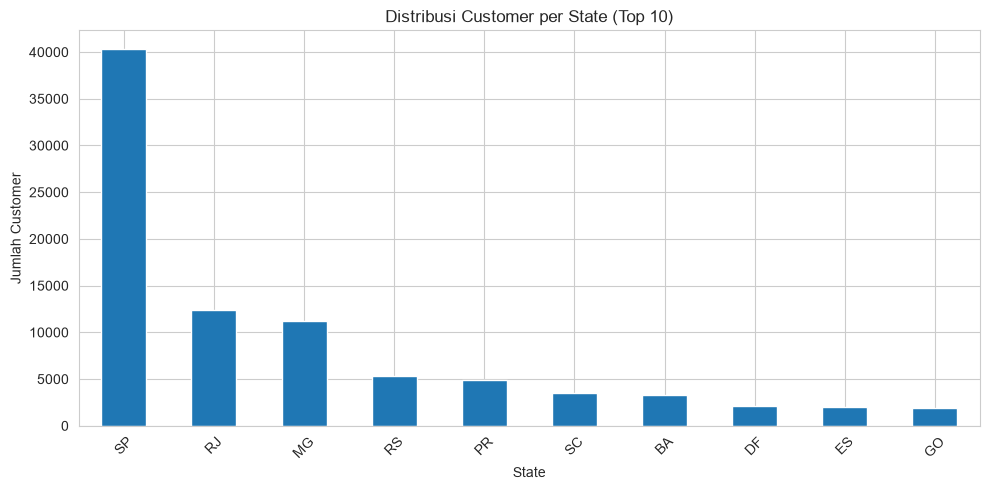

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
top_states.plot(kind="bar", ax=ax)
ax.set_title("Distribusi Customer per State (Top 10)")
ax.set_xlabel("State")
ax.set_ylabel("Jumlah Customer")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


---
## 5.3 Product Analytics

Top categories, produk terlaris, kategori berkinerja rendah.


In [7]:
print("Kategori dengan transaction value tertinggi:")
print(product_analytics.groupby("category")["transaction_value"].sum().sort_values(ascending=False).head(5))

print("\nProduk terlaris (units_sold):")
print(product_analytics.sort_values("units_sold", ascending=False)[
    ["product_id", "category", "units_sold", "transaction_value"]
].head(10))

print("\nKategori berkinerja rendah (transaction value terendah, min 5 produk dalam kategori):")
category_counts = product_analytics["category"].value_counts()
valid_categories = category_counts[category_counts >= 5].index
low_performing = (
    product_analytics[product_analytics["category"].isin(valid_categories)]
    .groupby("category")["transaction_value"].sum()
    .sort_values()
    .head(10)
)
print(low_performing)


Kategori dengan transaction value tertinggi:
category
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
Name: transaction_value, dtype: float64

Produk terlaris (units_sold):
                             product_id               category  units_sold  \
22112  aca2eb7d00ea1a7b8ebd4e68314663af        furniture_decor         527   
19742  99a4788cb24856965c36a24e339b6058         bed_bath_table         488   
8613   422879e10f46682990de24d770e7f83d           garden_tools         484   
7364   389d119b48cf3043d311335e499d9c6b           garden_tools         392   
7079   368c6c730842d78016ad823897a372db           garden_tools         388   
10840  53759a2ecddad2bb87a079a1f1519f73           garden_tools         373   
27039  d1c427060a0f73f6b889a5c7c61f2ac4  computers_accessories         343   
10867  53b36df67ebb7c41585e8d54d6772e08          watches_gifts         

---
## 5.4 Seller Analytics

Transaction value, volume order, delivery performance, review performance.


In [8]:
print("Top 10 seller berdasarkan transaction value:")
print(seller_analytics.sort_values("transaction_value", ascending=False)[
    ["seller_id", "seller_state", "orders", "transaction_value", "avg_review_score"]
].head(10))

print(f"\nAverage review score seller (keseluruhan): {seller_analytics['avg_review_score'].mean():.2f}")
print(f"Seller dengan avg_delivery_days NaN (semua order belum/tidak delivered): "
      f"{seller_analytics['avg_delivery_days'].isnull().sum()}")


Top 10 seller berdasarkan transaction value:
                             seller_id seller_state  orders  \
857   4869f7a5dfa277a7dca6462dcf3b52b2           SP    1132   
1013  53243585a1d6dc2643021fd1853d8905           BA     358   
881   4a3ca9315b744ce9f8e9374361493884           SP    1806   
3024  fa1c13f2614d7b5c4749cbc52fecda94           SP     585   
1535  7c67e1448b00f6e969d365cea6b010ab           SP     982   
1560  7e93a43ef30c4f03f38b393420bc753a           SP     336   
2643  da8622b14eb17ae2831f4ac5b9dab84a           SP    1314   
1505  7a67c85e85bb2ce8582c35f2203ad736           SP    1160   
192   1025f0e2d44d7041d6cf58b6550e0bfa           SP     915   
1824  955fee9216a65b617aa5c0531780ce60           SP    1287   

      transaction_value  avg_review_score  
857           229472.63          4.122822  
1013          222776.05          4.075980  
881           200472.92          3.803262  
3024          194042.03          4.340206  
1535          187923.89          3.341445

---
## 5.5 Delivery Analytics

Funnel Purchase → Approved → Carrier → Shipped → Delivered, avg delivery time, late delivery rate.


In [9]:
funnel = {
    "Purchase": orders["order_purchase_timestamp"].notnull().sum(),
    "Approved": orders["order_approved_at"].notnull().sum() if "order_approved_at" in orders.columns else None,
    "Delivered to Carrier": orders["order_delivered_carrier_date"].notnull().sum() if "order_delivered_carrier_date" in orders.columns else None,
    "Delivered to Customer": orders["order_delivered_customer_date"].notnull().sum(),
}
print("Delivery Funnel:")
for stage, count in funnel.items():
    print(f"  {stage}: {count:,}")


Delivery Funnel:
  Purchase: 99,441
  Approved: 99,281
  Delivered to Carrier: 97,658
  Delivered to Customer: 96,476


In [10]:
avg_delivery_days = orders["delivery_days"].mean()
print(f"Average delivery time (hanya order yang delivered): {avg_delivery_days:.2f} hari")

# Late delivery rate: delivered_customer_date > estimated_delivery_date
delivered_orders = orders[orders["order_delivered_customer_date"].notnull()].copy()
delivered_orders["is_late"] = (
    delivered_orders["order_delivered_customer_date"] > delivered_orders["order_estimated_delivery_date"]
)
late_rate = delivered_orders["is_late"].mean() * 100
print(f"Late delivery rate (dari order yang delivered): {late_rate:.2f}%")


Average delivery time (hanya order yang delivered): 12.09 hari
Late delivery rate (dari order yang delivered): 8.11%


Avg delivery days per state (Top 10 terlama):
customer_state
RR    28.975610
AP    26.731343
AM    25.986207
AL    24.040302
PA    23.316068
MA    21.117155
SE    21.029851
CE    20.817826
AC    20.637500
PB    19.953578
Name: delivery_days, dtype: float64


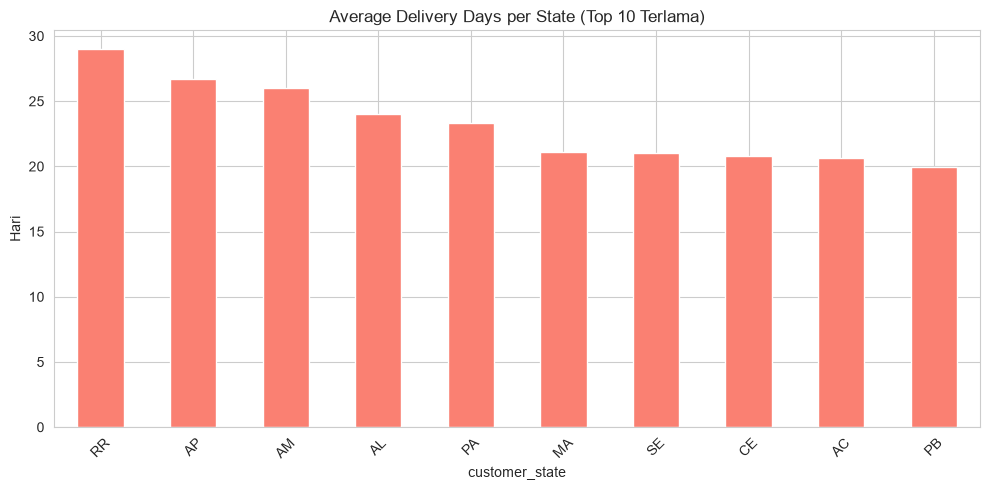

In [11]:
delivery_by_state = orders.merge(
    pd.DataFrame(list(db["customers_raw"].find({}, {"_id": 0})))[["customer_id", "customer_state"]],
    on="customer_id", how="left"
).groupby("customer_state")["delivery_days"].mean().sort_values(ascending=False)

print("Avg delivery days per state (Top 10 terlama):")
print(delivery_by_state.head(10))

fig, ax = plt.subplots(figsize=(10, 5))
delivery_by_state.head(10).plot(kind="bar", ax=ax, color="salmon")
ax.set_title("Average Delivery Days per State (Top 10 Terlama)")
ax.set_ylabel("Hari")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


---
## Definition of Done (Fase 5)

- [ ] Sales performance dianalisis (total transaction value, trend bulanan, kategori terbesar)
- [ ] Customer analytics dianalisis (total, repeat, distribusi state)
- [ ] Product analytics dianalisis (top categories, produk terlaris, kategori lemah)
- [ ] Seller analytics dianalisis (top seller, review, delivery)
- [ ] Delivery analytics dianalisis (funnel, avg delivery time, late delivery rate, per state)
- [ ] Semua terminologi konsisten pakai `transaction_value`, bukan "revenue"

**Lanjut ke:** `06_customer_segmentation.ipynb`
